Statistics from Stock Data
In this lab we will load stock data into a Pandas Dataframe and calculate some statistics on it. We will be working with stock data from Google, Apple, and Amazon. All the stock data was downloaded from yahoo finance in CSV format. In your workspace you should have a file named GOOG.csv containing the Google stock data, a file named AAPL.csv containing the Apple stock data, and a file named AMZN.csv containing the Amazon stock data. (You can see the workspace folder by clicking on the Jupyter logo in the upper left corner of the workspace. The solution notebook is also available there.) All the files contain 7 columns of data:

Date Open High Low Close Adj_Close Volume

We will start by reading in any of the above CSV files into a DataFrame and see what the data looks like.

In [2]:
# We import pandas into Python
import pandas as pd

# We read in a stock data data file into a data frame and see what it looks like
df = pd.read_csv('./financial_datasets/GOOG.csv')

# We display the first 5 rows of the DataFrame
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2004-08-19,49.676899,51.693783,47.669952,49.845802,49.845802,44994500
1,2004-08-20,50.178635,54.187561,49.925285,53.805050,53.805050,23005800
2,2004-08-23,55.017166,56.373344,54.172661,54.346527,54.346527,18393200
3,2004-08-24,55.260582,55.439419,51.450363,52.096165,52.096165,15361800
4,2004-08-25,52.140873,53.651051,51.604362,52.657513,52.657513,9257400


We clearly see that the Dataframe has automatically labeled the row indices using integers and has labeled the columns of the DataFrame using the names of the columns in the CSV files.

To Do
You will now load the stock data from Google, Apple, and Amazon into separte DataFrames. However, for each stock data you will only be interested in loading the Date and Adj Close columns into the Dataframe. In addtion, you want to use the Date column as your row index. Finally, you want the DataFrame to recognize the dates as actual dates (year/month/day) and not as strings. For each stock, you can accomplish all theses things in just one line of code by using the appropiate keywords in the pd.read_csv() function. Here are a few hints:

Use the index_col keyword to indicate which column you want to use as an index. For example index_col = ['Open']

Set the parse_dates keyword equal to True to convert the Dates into real dates of the form year/month/day

Use the usecols keyword to select which columns you want to load into the DataFrame. For example usecols = ['Open', 'High']

Fill in the code below:

In [4]:
# We load the Google stock data into a DataFrame

google_stock = pd.read_csv('./financial_datasets/GOOG.csv', usecols = ['Adj Close', 'Date'], index_col=['Date'], parse_dates=True)

# We load the Apple stock data into a DataFrame

apple_stock = pd.read_csv('./financial_datasets/AAPL.csv', usecols = ['Adj Close', 'Date'], index_col = ['Date'], parse_dates = True)

# We load the Amazon stock data into a DataFrame

amazon_stock = pd.read_csv('./financial_datasets/AMZN.csv', usecols = ['Adj Close', 'Date'], index_col = ['Date'], parse_dates = True)

You can check that you have loaded the data correctly by displaying the head of the DataFrames.

In [5]:
print(google_stock.head())

            Adj Close
Date                 
2004-08-19  49.845802
2004-08-20  53.805050
2004-08-23  54.346527
2004-08-24  52.096165
2004-08-25  52.657513


In [6]:
print(apple_stock.head())

            Adj Close
Date                 
2000-01-03   3.596616
2000-01-04   3.293384
2000-01-05   3.341579
2000-01-06   3.052405
2000-01-07   3.196992


In [7]:
print(amazon_stock.head())

            Adj Close
Date                 
2000-01-03    89.3750
2000-01-04    81.9375
2000-01-05    69.7500
2000-01-06    65.5625
2000-01-07    69.5625


You will now join the three DataFrames above to create a single new DataFrame that contains all the Adj Close for all the stocks. Let's start by creating an empty DataFrame that has as row indices calendar days between 2000-01-01 and 2016-12-31. We will use the pd.date_range() function to create the calendar dates first and then we will create a DataFrame that uses those dates as row indices:

In [ ]:
#We create calendar dates between '2000-01-01' and '2016-12-31'

dates = pd.date_range('2000-01-01' , '2016-12-31')

#We create an empty DateFrame that uses the above dates as indices

all_stocks = pd.DataFrame(index=dates)

To Do
You will now join the the individual DataFrames, google_stock, apple_stock, and amazon_stock, to the all_stocks DataFrame. However, before you do this, it is necessary that you change the name of the columns in each of the three dataframes. This is because the column labels in the all_stocks dataframe must be unique. Since all the columns in the individual dataframes have the same name, Adj Close, we must change them to the stock name before joining them. In the space below change the column label Adj Close of each individual dataframe to the name of the corresponding stock. You can do this by using the pd.DataFrame.rename() function.

In [9]:
# Change the Adj Close column label to Google
google_stock = google_stock.rename(columns = {'Adj Close': 'google'})

# Change the Adj Close column label to Apple
apple_stock = apple_stock.rename(columns = {'Adj Close' : 'apple'})

# Change the Adj Close column label to Amazon
amazon_stock = amazon_stock.rename(columns = {'Adj Close' : 'amazon'})

You can check that the column labels have been changed correctly by displaying the datadrames

In [10]:
# We display the google_stock DataFrame
google_stock.head()

,google
Date,
2004-08-19,49.845802
2004-08-20,53.805050
2004-08-23,54.346527
2004-08-24,52.096165
2004-08-25,52.657513


In [11]:
# We display the google_stock DataFrame
apple_stock.head()

,apple
Date,
2000-01-03,3.596616
2000-01-04,3.293384
2000-01-05,3.341579
2000-01-06,3.052405
2000-01-07,3.196992


In [12]:
# We display the google_stock DataFrame
amazon_stock.head()

,amazon
Date,
2000-01-03,89.3750
2000-01-04,81.9375
2000-01-05,69.7500
2000-01-06,65.5625
2000-01-07,69.5625


Now that we have unique column labels, we can join the individual DataFrames to the all_stocks DataFrame. For this we will use the dataframe.join() function. The function dataframe1.join(dataframe2) joins dataframe1 with dataframe2. We will join each dataframe one by one to the all_stocks dataframe. Fill in the code below to join the dataframes, the first join has been made for you:

In [13]:
#We join the Google stock to all_stocks
all_stocks = all_stocks.join(google_stock)

#We join the apple stock to all_stocks
all_stocks = all_stocks.join(apple_stock)

#We join the amazon stock to all_stocks
all_stocks = all_stocks.join(amazon_stock)

You can check that the dataframes have been joined correctly by displaying the all_stocks dataframe

In [15]:
# We display the all_stocks DataFrame
all_stocks.head()

,google,apple,amazon
2000-01-01,NaN,NaN,NaN
2000-01-02,NaN,NaN,NaN
2000-01-03,NaN,3.596616,89.3750
2000-01-04,NaN,3.293384,81.9375
2000-01-05,NaN,3.341579,69.7500


In [20]:
# Describe the all_stocks DataFrame
print(all_stocks.describe())


            google        apple       amazon
count  3115.000000  4277.000000  4277.000000
mean    347.420229    35.222976   166.095436
std     187.671596    37.945557   189.212345
min      49.681866     0.843106     5.970000
25%     220.088539     3.221090    38.009998
50%     286.397247    17.524017    76.980003
75%     508.255340    64.533600   243.919998
max     813.109985   126.941574   844.359985


In [19]:
# get the info of the all_stocks DataFrame
print(all_stocks.info())

<class 'pandas.DataFrame'>
DatetimeIndex: 6210 entries, 2000-01-01 to 2016-12-31
Freq: D
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   google  3115 non-null   float64
 1   apple   4277 non-null   float64
 2   amazon  4277 non-null   float64
dtypes: float64(3)
memory usage: 194.1 KB
None


To Do
Before we proceed to get some statistics on the stock data, let's first check that we don't have any NaN values. In the space below check if there are any NaN values in the all_stocks dataframe. If there are any, remove any rows that have NaN values:

In [21]:
# Print the column-wise count of NaN values, if any, in the all_stocks dataframe
print(all_stocks.isnull().sum())

google    3095
apple     1933
amazon    1933
dtype: int64


In [ ]:
# Remove any rows that contain NaN values. Do this operation inplace. 
all_stocks.dropna(inplace=True, axis=0)

print(all_stocks.head())

               google     apple     amazon
2004-08-19  49.845802  1.973460  38.630001
2004-08-20  53.805050  1.979244  39.509998
2004-08-23  54.346527  1.997236  39.450001
2004-08-24  52.096165  2.053144  39.049999
2004-08-25  52.657513  2.123831  40.299999


In [24]:
print(all_stocks.tail())

                google       apple      amazon
2016-12-23  789.909973  115.088142  760.590027
2016-12-27  791.549988  115.819054  771.400024
2016-12-28  785.049988  115.325203  772.130005
2016-12-29  782.789978  115.295570  765.150024
2016-12-30  771.820007  114.396751  749.869995


In [26]:
print(all_stocks.isnull().sum())

google    0
apple     0
amazon    0
dtype: int64


Now that you have eliminated any NaN values we can now calculate some basic statistics on the stock prices. Fill in the code below

In [28]:
# Print the average stock price for each stock
print(all_stocks.mean())

print()
# Print the median stock price for each stock
print(all_stocks.median())

print()
# Print the standard deviation of the stock price for each stock  
print(all_stocks.std())

print()
# Print the correlation between stocks
print(all_stocks.corr())

google    347.420229
apple      47.736018
amazon    216.598177
dtype: float64

google    286.397247
apple      39.461483
amazon    161.820007
dtype: float64

google    187.671596
apple      37.421555
amazon    199.129792
dtype: float64

          google     apple    amazon
google  1.000000  0.900242  0.952444
apple   0.900242  1.000000  0.886321
amazon  0.952444  0.886321  1.000000


We will now look at how we can compute some rolling statistics, also known as moving statistics. We can calculate for example the rolling mean (moving average) of the Google stock price by using the Pandas dataframe.rolling().mean() method. The dataframe.rolling(N).mean() calculates the rolling mean over an N-day window. In other words, we can take a look at the average stock price every N days using the above method. Fill in the code below to calculate the average stock price every 150 days for Google stock

In [30]:
#We compute the rolling mean using a 150-day window for google stock

rollingMean = all_stocks['google'].rolling(150).mean()
print(rollingMean)

2004-08-19           NaN
2004-08-20           NaN
2004-08-23           NaN
2004-08-24           NaN
2004-08-25           NaN
                 ...    
2016-12-23    758.236666
2016-12-27    758.713066
2016-12-28    759.111599
2016-12-29    759.502732
2016-12-30    759.763799
Name: google, Length: 3115, dtype: float64


We can also visualize the rolling mean by plotting the data in our dataframe. In the following lessons you will learn how to use Matplotlib to visualize data. For now I will just import matplotlib and plot the Google stock data on top of the rolling mean. You can play around by changing the rolling mean window and see how the plot changes.

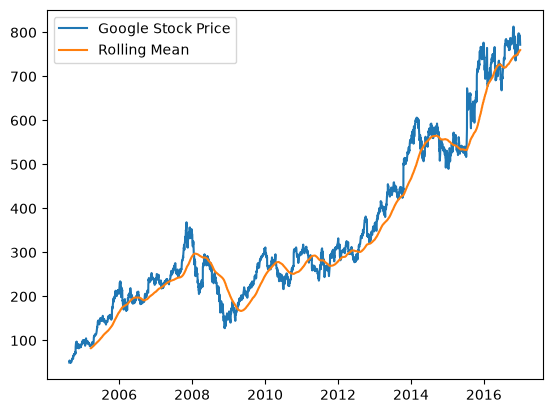

In [38]:
#this allows plots to be rendered in the notebook
%matplotlib inline

#We inport matplotlib into python
import matplotlib.pyplot as plt

#We plot the google stock data 
plt.plot(all_stocks['google'])

#We plot the rolling mean ontop of the google stock data
plt.plot(rollingMean)

#We create a legend to show what each plot represents
plt.legend(['Google Stock Price', 'Rolling Mean'])

#We display the line plot 
plt.show()